# House Price Prediction

## Notebook 5 — Hyperparameter Tuning

### Objectives

- Load processed datasets
- Tune the XGBoost model using RandomizedSearchCV
- Evaluate the optimized model
- Save the tuned model

Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd

from pathlib import Path

from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Paths

In [3]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"

Load Data

In [4]:
X_train = pd.read_csv(PROCESSED / "X_train.csv")
X_valid = pd.read_csv(PROCESSED / "X_valid.csv")

y_train = pd.read_csv(PROCESSED / "y_train.csv").squeeze()
y_valid = pd.read_csv(PROCESSED / "y_valid.csv").squeeze()

Base Model

In [5]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

Parameter Grid

In [6]:
param_grid = {

    "n_estimators":[200,300,500],

    "max_depth":[3,4,5,6,8],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "subsample":[0.7,0.8,0.9,1.0],

    "colsample_bytree":[0.7,0.8,0.9,1.0],

    "min_child_weight":[1,3,5],

    "gamma":[0,0.1,0.3]
}

Randomized Search

In [7]:
search = RandomizedSearchCV(

    estimator=xgb,

    param_distributions=param_grid,

    n_iter=25,

    scoring="neg_root_mean_squared_error",

    cv=5,

    random_state=42,

    verbose=2,

    n_jobs=-1
)

Train

In [8]:
search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,25
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


Best Parameters

In [9]:
search.best_params_

{'subsample': 0.9,
 'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 4,
 'learning_rate': 0.05,
 'gamma': 0,
 'colsample_bytree': 0.8}

Best Score

In [10]:
print(search.best_score_)

-27851.54140625


Best Model

In [11]:
best_model = search.best_estimator_

Predictions

In [12]:
predictions = best_model.predict(
    X_valid
)

Evaluation

In [13]:
rmse = np.sqrt(
    mean_squared_error(
        y_valid,
        predictions
    )
)

mae = mean_absolute_error(
    y_valid,
    predictions
)

r2 = r2_score(
    y_valid,
    predictions
)

print(f"RMSE : {rmse:,.2f}")
print(f"MAE  : {mae:,.2f}")
print(f"R²   : {r2:.4f}")

RMSE : 26,397.78
MAE  : 16,499.98
R²   : 0.9092


Save Model

In [14]:
joblib.dump(
    best_model,
    MODELS/"best_xgboost.pkl"
)

print("Model saved.")

Model saved.


Feature Importance

In [15]:
importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
4,OverallQual,0.167410
26,GarageCars,0.158330
151,ExterQual_TA,0.084386
213,GarageFinish_Unf,0.064010
19,FullBath,0.031098
16,GrLivArea,0.030478
196,KitchenQual_TA,0.029456
111,RoofMatl_CompShg,0.028704
15,LowQualFinSF,0.024402
163,BsmtQual_TA,0.021371


Plot Feature Importance

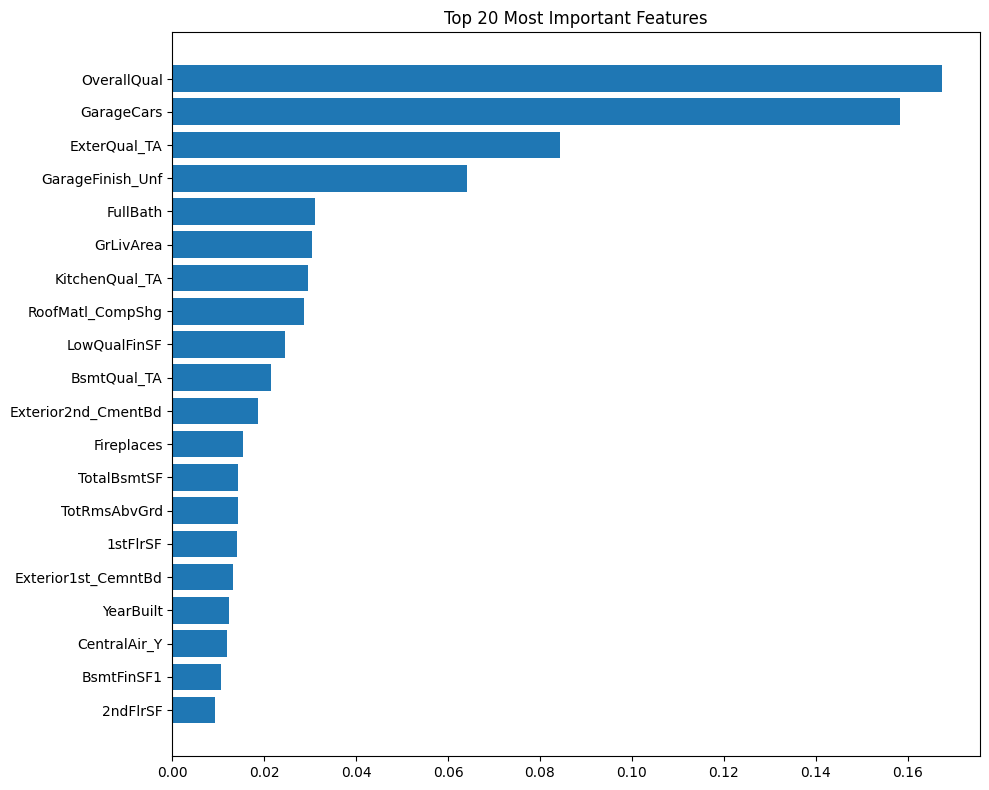

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")

plt.tight_layout()

plt.show()

Save Importance

In [17]:
importance.to_csv(

    ROOT/"reports"/"feature_importance.csv",

    index=False
)